In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [258]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [259]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [260]:
df = pd.read_csv("../../data/raw/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [261]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [262]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [263]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [264]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [265]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6334 - loss: 0.6832 - val_accuracy: 0.6423 - val_loss: 0.6757
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6597 - val_accuracy: 0.6423 - val_loss: 0.6657
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6538 - loss: 0.6465 - val_accuracy: 0.6423 - val_loss: 0.6583
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6517 - loss: 0.6347 - val_accuracy: 0.6423 - val_loss: 0.6483
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6497 - loss: 0.6230 - val_accuracy: 0.6341 - val_loss: 0.6369
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6558 - loss: 0.6123 - val_accuracy: 0.6423 - val_loss: 0.6261
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6741 - loss: 0.6024 - val_accuracy: 0.6260 - val_loss: 0.6154
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6782 - loss: 0.5933 - val_accuracy: 0.6423 - val_loss:

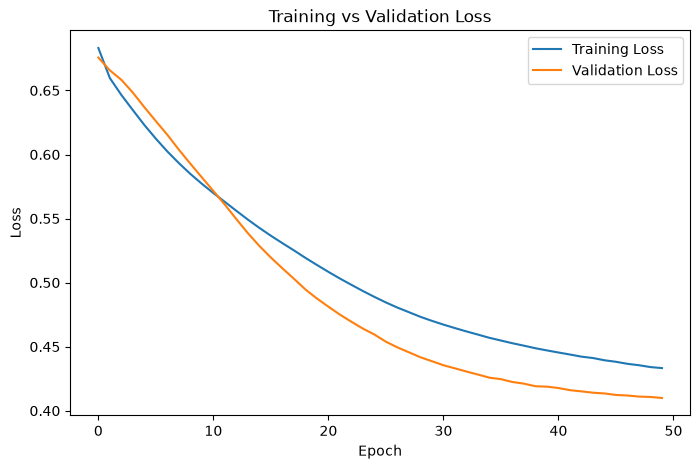

In [266]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [267]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# Predictions
y_prob = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC-ROC:", auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy: 0.7532467532467533
Precision: 0.6818181818181818
Recall: 0.5555555555555556
F1: 0.6122448979591837
AUC-ROC: 0.8466666666666667


ROC data saved successfully.


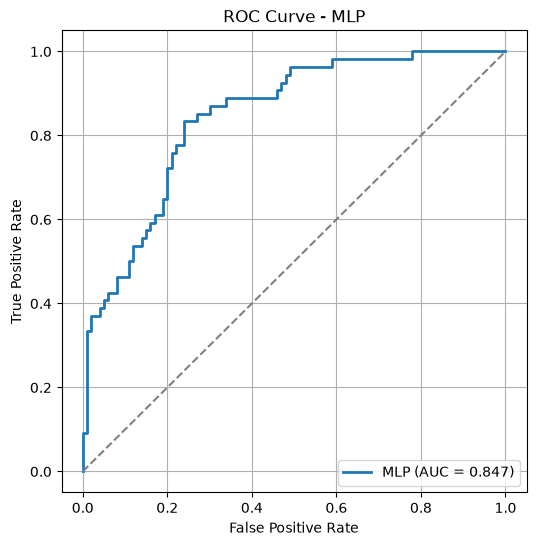

ROC curve saved successfully.


In [268]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


os.makedirs("../../results/roc", exist_ok=True)

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

roc_df.to_csv(
    "../../results/roc/roc_mlp.csv",
    index=False
)

print("ROC data saved successfully.")

# Create figures folder
os.makedirs("../../figures", exist_ok=True)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MLP (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../../figures/roc_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

In [269]:
import pandas as pd

mlp_result = pd.DataFrame({
    "model": ["MLP"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

mlp_result

,model,accuracy,precision,recall,f1,auc_roc
0,MLP,0.753247,0.681818,0.555556,0.612245,0.846667


In [270]:
mlp_result.to_csv(
    "../results/results_log.csv",
    mode="a",
    header=False,
    index=False
)

print("MLP results saved!")

MLP results saved!


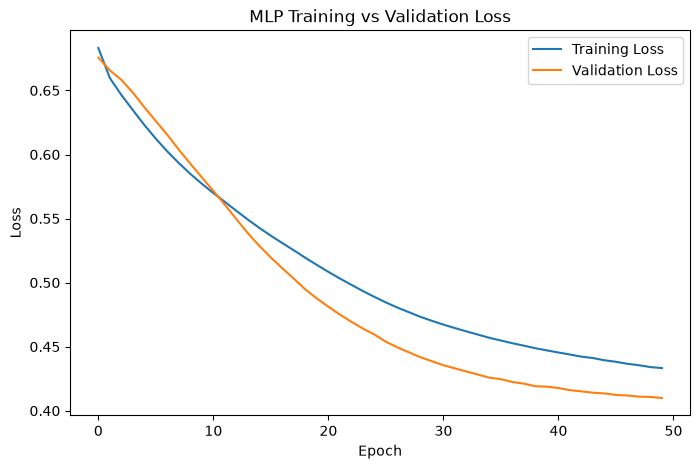

In [271]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()

plt.savefig("../results/mlp_loss_curve.png")

plt.show()

In [272]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

import numpy as np
import pandas as pd
import json

In [273]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [274]:
def build_model():

    model = Sequential([
        Dense(64, activation='relu',
              input_shape=(X_train.shape[1],)),

        Dropout(0.3),

        Dense(32, activation='relu'),

        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [275]:
model_32 = build_model()

history_32 = model_32.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4623 - loss: 0.7001 - val_accuracy: 0.6423 - val_loss: 0.6787 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6578 - loss: 0.6641 - val_accuracy: 0.6423 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6456 - loss: 0.6627 - val_accuracy: 0.6423 - val_loss: 0.6653 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6578 - loss: 0.6596 - val_accuracy: 0.6423 - val_loss: 0.6608 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6558 - loss: 0.6542 - val_accuracy: 0.6423 - val_loss: 0.6552 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6477 - loss: 0.6577 - val_accuracy: 0.6423 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6558 - loss: 0.6511 - val_accuracy:

In [276]:
model_64 = build_model()

history_64 = model_64.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5662 - loss: 0.6868 - val_accuracy: 0.6341 - val_loss: 0.6744 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6415 - loss: 0.6724 - val_accuracy: 0.6341 - val_loss: 0.6663 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6436 - loss: 0.6647 - val_accuracy: 0.6423 - val_loss: 0.6648 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 0.6594 - val_accuracy: 0.6423 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6875 - loss: 0.6527
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6558 - loss: 0.6553 - val_accuracy: 0.6423 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6558 - loss: 0.6452 - val_accuracy: 0.6423 - val_

In [277]:
model_128 = build_model()

history_128 = model_128.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/50


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5621 - loss: 0.6831 - val_accuracy: 0.6423 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6171 - loss: 0.6750 - val_accuracy: 0.6423 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6375 - loss: 0.6737 - val_accuracy: 0.6423 - val_loss: 0.6677 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6497 - loss: 0.6722 - val_accuracy: 0.6423 - val_loss: 0.6650 - learning_rate: 0.0010
Epoch 5/50
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6328 - loss: 0.6640
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6599 - loss: 0.6598 - val_accuracy: 0.6423 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6701 - loss: 0.6548 - val_accuracy: 0.6423 - val_loss: 0.661

In [278]:
best_32 = max(history_32.history['val_accuracy'])

best_64 = max(history_64.history['val_accuracy'])

best_128 = max(history_128.history['val_accuracy'])

print("Batch 32 :", best_32)
print("Batch 64 :", best_64)
print("Batch 128:", best_128)

Batch 32 : 0.8211382031440735
Batch 64 : 0.642276406288147
Batch 128: 0.642276406288147


In [279]:
results = {
    32: best_32,
    64: best_64,
    128: best_128
}

best_batch = max(results, key=results.get)

print("Best Batch Size:", best_batch)

Best Batch Size: 32


In [280]:
best_config = {
    "model": "MLP",
    "hidden_layers": [64, 32],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": int(best_batch),
    "best_validation_accuracy": float(results[best_batch])
}

In [281]:
with open("../results/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("best_config.json saved")

best_config.json saved


In [282]:
with open("../results/best_config.json") as f:
    print(f.read())

{
    "model": "MLP",
    "hidden_layers": [
        64,
        32
    ],
    "dropout": 0.3,
    "optimizer": "Adam",
    "epochs": 50,
    "batch_size": 32,
    "best_validation_accuracy": 0.8211382031440735
}


In [283]:
%who

ConfusionMatrixDisplay	 Dense	 Dropout	 MinMaxScaler	 ReduceLROnPlateau	 Sequential	 X	 X_test	 X_train	 
accuracy	 accuracy_score	 auc	 ax	 best_128	 best_32	 best_64	 best_batch	 best_config	 
build_model	 cm	 confusion_matrix	 df	 disp	 f	 f1	 f1_score	 fig	 
fpr	 history	 history_128	 history_32	 history_64	 json	 mlp_result	 model	 model_128	 
model_32	 model_64	 np	 os	 pd	 plt	 precision	 precision_score	 random	 
recall	 recall_score	 reduce_lr	 results	 roc_auc_score	 roc_curve	 roc_df	 scaler	 tf	 
thresholds	 tpr	 train_test_split	 y	 y_pred	 y_prob	 y_test	 y_train	 


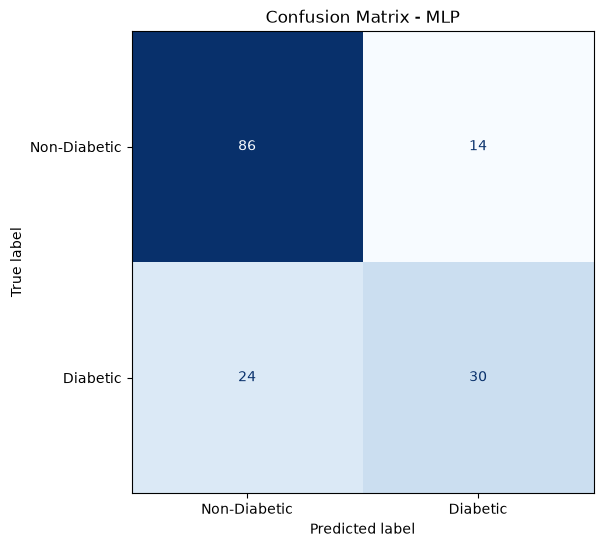

Confusion matrix saved successfully!


In [284]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create folder
os.makedirs("../../figures", exist_ok=True)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("Confusion Matrix - MLP")

plt.savefig(
    "../../results/matrix/confusion_matrix_mlp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully!")